# Phase 16: Flutter Image Preprocessing Specification

This notebook documents the exact mathematical image transformations required to feed input frames into the ONNX models, ensuring on-device Dart preprocessing yields identical outputs to the Python PyTorch training setup.

### 1. Preprocessing Sequence Specification

1.  **Image Resize**: Resize the input frame to exactly **$224 \times 224$** pixels for the classifier, and **$416 \times 416$** pixels for the leaf detector.
2.  **Color Space**: Convert the image to standard **RGB** (dropping any alpha/transparency channels).
3.  **Pixel Normalization**: Convert pixel bytes `[0, 255]` to floats `[0.0, 1.0]` by dividing by `255.0`.
4.  **ImageNet Standardization (Classifier Only)**:
    *   Subtract Channel Means: $R - 0.485$, $G - 0.456$, $B - 0.406$
    *   Divide by Channel Stds: $R / 0.229$, $G / 0.224$, $B / 0.225$
5.  **Channel Transposition**: Re-order the array dimensions from **Height-Width-Channel (HWC)** format to **Channel-Height-Width (CHW)** format.
6.  **Batch Expansion**: Add a batch dimension at axis `0`, resulting in a shape of `[1, 3, 224, 224]` (Float32).

### 2. Preprocessing Demonstration in Python

Run the self-contained cell below to load a sample image from the validation split and visualize the preprocessing stages.

[INFO] Loading sample image: O:\Hackthons\KrishiOS\ai\datasets\classification\plantvillage\val\Apple___Apple_scab\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG


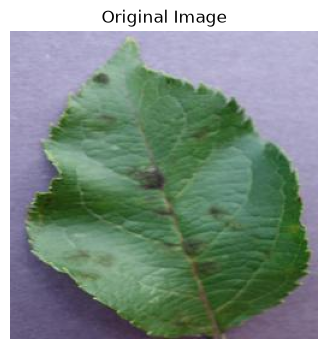

Shape after resize: (224, 224, 3) (HWC)
Final Input Tensor shape: (1, 3, 224, 224) (BCHW)
First 5 normalized R-channel values:
 [0.74193005 0.7248053  0.70768054 0.69055579 0.70768054]


In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# 1. Setup paths
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'ai' and PROJECT_ROOT.parent != PROJECT_ROOT:
    if (PROJECT_ROOT / 'ai').exists():
        PROJECT_ROOT = PROJECT_ROOT / 'ai'
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils

# 2. Locate sample validation image
val_images = list((utils.paths.CLASSIFICATION_DATASET_DIR / "val").glob("**/*.jpg")) + \
             list((utils.paths.CLASSIFICATION_DATASET_DIR / "val").glob("**/*.JPG"))

if val_images:
    sample_path = val_images[0]
    print(f"[INFO] Loading sample image: {sample_path}")
    img = Image.open(sample_path).convert("RGB")
    
    # Visual display
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()
    
    # A. Resize to 224x224
    img_resized = img.resize((utils.config.IMAGE_SIZE, utils.config.IMAGE_SIZE))
    
    # B. Cast to Float32 and divide by 255
    img_arr = np.array(img_resized).astype(np.float32) / 255.0
    print(f"Shape after resize: {img_arr.shape} (HWC)")
    
    # C. ImageNet Standardization
    mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
    std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)
    img_standardized = (img_arr - mean) / std
    
    # D. Transpose to CHW shape [3, 224, 224]
    img_chw = img_standardized.transpose(2, 0, 1)
    
    # E. Expand Batch dimension [1, 3, 224, 224]
    input_tensor = np.expand_dims(img_chw, axis=0)
    print(f"Final Input Tensor shape: {input_tensor.shape} (BCHW)")
    print("First 5 normalized R-channel values:\n", input_tensor[0, 0, 0, :5])
else:
    print("⚠️ No images found in classification validation split.")

### 3. Reference Dart/Flutter Preprocessing Implementation

Use the following structure inside your mobile client to process input bytes:

In [4]:
# Reference Dart code for copy-pasting
dart_code = """
Float32List preprocessImage(Image img, int targetSize, {bool normalize = true}) {
  final floatBuffer = Float32List(1 * 3 * targetSize * targetSize);
  
  final mean = [0.485, 0.456, 0.406];
  final std = [0.229, 0.224, 0.225];
  
  int pixelIndex = 0;
  for (int c = 0; c < 3; c++) {
    for (int y = 0; y < targetSize; y++) {
      for (int x = 0; x < targetSize; x++) {
        final pixel = img.getPixel(x, y);
        double val = (c == 0 ? pixel.r : (c == 1 ? pixel.g : pixel.b)) / 255.0;
        
        if (normalize) {
          val = (val - mean[c]) / std[c];
        }
        
        // Write directly in Channel-Height-Width (CHW) transpose indexing
        floatBuffer[c * targetSize * targetSize + y * targetSize + x] = val;
      }
    }
  }
  return floatBuffer;
}
"""
print(dart_code)


Float32List preprocessImage(Image img, int targetSize, {bool normalize = true}) {
  final floatBuffer = Float32List(1 * 3 * targetSize * targetSize);

  final mean = [0.485, 0.456, 0.406];
  final std = [0.229, 0.224, 0.225];

  int pixelIndex = 0;
  for (int c = 0; c < 3; c++) {
    for (int y = 0; y < targetSize; y++) {
      for (int x = 0; x < targetSize; x++) {
        final pixel = img.getPixel(x, y);
        double val = (c == 0 ? pixel.r : (c == 1 ? pixel.g : pixel.b)) / 255.0;

        if (normalize) {
          val = (val - mean[c]) / std[c];
        }

        // Write directly in Channel-Height-Width (CHW) transpose indexing
        floatBuffer[c * targetSize * targetSize + y * targetSize + x] = val;
      }
    }
  }
  return floatBuffer;
}

